
###########################################################################
# convergence_extended_AB1.py
# Asymptotic evolution for Configurations A and B1 (a > 1)
# x_o^f is UNSTABLE — system does NOT converge to it
###########################################################################

[Configuration A]
  Integrating ODE (1895-2500) ... done.
  Computing x_o*(t), x_o†(t) series ... done.

  ASYMPTOTIC EVOLUTION — Configuration A
  a = 1.25 (a > 1 → x_o^f UNSTABLE repeller)
  x_o^f      = 0.000616  [ASM FP, UNSTABLE — NOT approached]
  x_o*(∞)    = nan  [limiting attractor as I→K_I, g→0]
  Δ_shift(∞) = x_o*(∞) - x_o^f = +nan  [REMAINS POSITIVE]
  -------------------------------------------------------------------------

  Sample trajectory values:
    2020: x_o = 0.59493   gap to x_o^f: +0.59432   gap to x_o*(∞): +nan
    2050: x_o = 0.75396   gap to x_o^f: +0.75334   gap to x_o*(∞): +nan
    2100: x_o = 0.89979   gap to x_o^f: +0.89918   gap to x_o*(∞): +nan
    2200: x_o = 0.

/tmp/ipykernel_113893/2133425483.py:438: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()



  Saved: plots/fp_comparison/convergence_extended_AB1.jpg


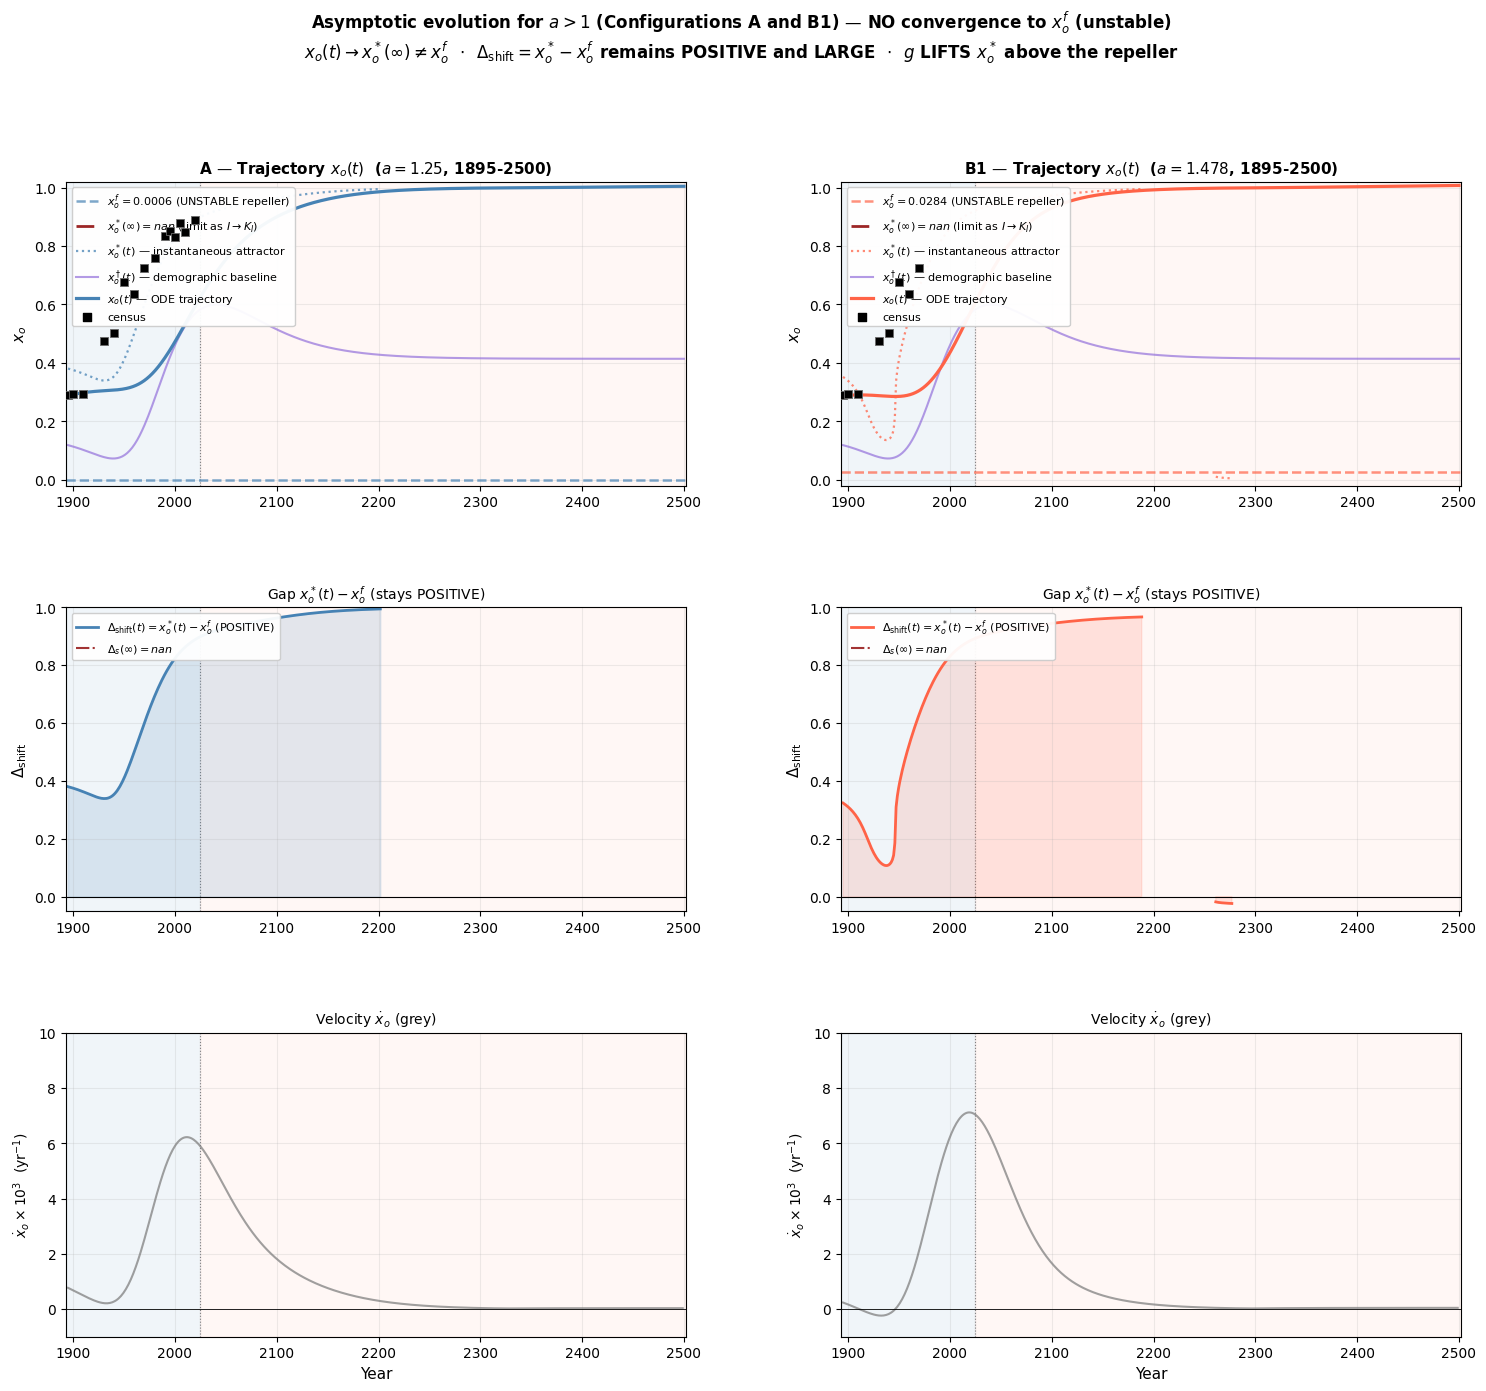

In [6]:
"""
26 Feb 2026
convergence_extended_AB1.py
============================
Asymptotic evolution for Configurations A and B1 (a > 1).

Unlike B2 where x_o(t) → x_o^f (stable attractor), in A and B1 the linguistic
fixed point x_o^f is UNSTABLE (repeller). The system does NOT converge to x_o^f.

Instead, we show:
  1. x_o*(t) — instantaneous attractor of f+g
  2. x_o^f   — unstable linguistic FP (horizontal line, NOT approached)
  3. Δ_shift(t) = x_o*(t) - x_o^f — gap that INCREASES over time
  4. x_o*(∞)  — limiting value of x_o* as I → K_I (g → 0 but x_o* ≠ x_o^f)

Key result: As g → 0, the system approaches x_o*(∞) which is DIFFERENT from
x_o^f because x_o^f is unstable. The gap Δ_shift remains POSITIVE and LARGE.

Author: Riccardo Del Gratta
Date: February 2026
"""

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy.integrate import solve_ivp
from scipy.optimize import brentq
import warnings
import os

# ============================================================================
# MODEL PARAMETERS
# ============================================================================

N0_indigenous = 1012848
K_indigenous  = 12918933
r_indigenous  = 0.022

N0_spanish = 3117878
K_spanish  = 165995301
r_spanish  = 0.037

A_p   = 5.47
nu    = 0.271
p_max = 0.97

base_year = 1895

# Configuration A — Single-fit (1895-2020)
S_O_A = 0.0349
S_L_A = 0.0055
A_A   = 1.25

# Configuration B1 — Consensus (1895-1970)
S_O_B1 = 0.0454
S_L_B1 = 0.00839
A_B1   = 1.478

# Census data
CENSUS_A = {
    1895: 0.2886, 1900: 0.2949, 1910: 0.2951, 1930: 0.4754,
    1940: 0.5032, 1950: 0.6752, 1960: 0.6353, 1970: 0.7235,
    1980: 0.7591, 1990: 0.8352, 1995: 0.8519, 2000: 0.8310,
    2005: 0.8772, 2010: 0.8479, 2020: 0.8895,
}

CENSUS_B1 = {yr: val for yr, val in CENSUS_A.items() if yr <= 1970}


# ============================================================================
# CORE FUNCTIONS
# ============================================================================

def logistic(t, K, r, N0):
    return K / (1 + ((K - N0) / N0) * np.exp(-r * t))

def p_o_func(m):
    return p_max / (1 + A_p * np.exp(-nu * m))

def f_func(x_o, s_o, s_l, a):
    if x_o <= 0 or x_o >= 1:
        return 0.0
    with warnings.catch_warnings():
        warnings.simplefilter('ignore')
        return (s_o * x_o**a * (1 - x_o) - s_l * (1 - x_o)**a * x_o)

def g_func(x_o, p, m, I):
    return (p - x_o - p * (1 - p/p_max) * nu * m) * r_indigenous * (1 - I/K_indigenous)

def rhs_full(x_o, I, S, s_o, s_l, a):
    m = S / I if I > 0 else np.inf
    p = p_o_func(m)
    return f_func(x_o, s_o, s_l, a) + g_func(x_o, p, m, I)

def demographic_fp(I, S):
    """x_o† = zero of g alone."""
    m  = S / I
    p  = p_o_func(m)
    xd = p * (1.0 - (1.0 - p/p_max) * nu * m)
    return xd if 0 < xd < 1 else np.nan

def find_stable_fp(I, S, s_o, s_l, a, n=3000):
    """Stable interior FP of f+g at fixed (I, S)."""
    xs   = np.linspace(0.005, 0.995, n)
    vals = np.array([rhs_full(x, I, S, s_o, s_l, a) for x in xs])
    for idx in np.where(np.diff(np.sign(vals)))[0]:
        try:
            xr = brentq(lambda x: rhs_full(x, I, S, s_o, s_l, a),
                        xs[idx], xs[idx+1], xtol=1e-10)
            sl = (rhs_full(xr+1e-6, I, S, s_o, s_l, a) 
                 - rhs_full(xr-1e-6, I, S, s_o, s_l, a)) / 2e-6
            if sl < 0:
                return xr
        except Exception:
            pass
    return np.nan

def asm_fp(s_o, s_l, a):
    """x_o^f = 1/(1+β),  β = (s_o/s_l)^{1/(a-1)}"""
    if abs(a - 1) < 1e-12:
        return np.nan
    beta = (s_o / s_l) ** (1.0 / (a - 1.0))
    xf   = 1.0 / (1.0 + beta)
    return xf

def xstar_infinity(s_o, s_l, a):
    """
    x_o*(∞) = stable FP of f+g when I → K_I (g → 0).
    This is NOT equal to x_o^f (which is unstable for a>1).
    As g → 0, the system approaches a limit that depends on the 
    final value of p_o at I=K_I, S=K_S.
    """
    I_inf = K_indigenous * 0.9999
    S_inf = K_spanish * 0.9999
    return find_stable_fp(I_inf, S_inf, s_o, s_l, a)


# ============================================================================
# ODE INTEGRATION
# ============================================================================

def integrate_trajectory(t_start, t_end, x0, s_o, s_l, a, n_pts=50000):
    """Integrate ODE from x0 to t_end."""
    def ode(t, y):
        xv = float(np.clip(y[0], 0.001, 0.999))
        I  = logistic(t, K_indigenous, r_indigenous, N0_indigenous)
        S  = logistic(t, K_spanish,    r_spanish,    N0_spanish)
        return [rhs_full(xv, I, S, s_o, s_l, a)]

    t_eval = np.linspace(t_start, t_end, n_pts)
    sol    = solve_ivp(ode, [t_start, t_end], [x0],
                       t_eval=t_eval, method='RK45', rtol=1e-10, atol=1e-12)
    return base_year + sol.t, sol.y[0]


# ============================================================================
# TIME SERIES (x_o*(t), x_o†(t))
# ============================================================================

def compute_xstar_xdag_series(t_start, t_end, s_o, s_l, a, n_pts=500):
    """Compute x_o*(t) and x_o†(t)."""
    t_arr    = np.linspace(t_start, t_end, n_pts)
    year_arr = base_year + t_arr
    xstar    = np.full(n_pts, np.nan)
    xdag     = np.full(n_pts, np.nan)

    for k, t in enumerate(t_arr):
        I = logistic(t, K_indigenous, r_indigenous, N0_indigenous)
        S = logistic(t, K_spanish,    r_spanish,    N0_spanish)
        xstar[k] = find_stable_fp(I, S, s_o, s_l, a)
        xdag[k]  = demographic_fp(I, S)

    return year_arr, xstar, xdag


# ============================================================================
# SUMMARY TABLE
# ============================================================================

def print_asymptotic_summary(scenario_name, s_o, s_l, a, t_traj, x_traj, xf, xstar_inf):
    """Print summary of asymptotic behavior."""
    print("\n" + "=" * 75)
    print(f"  ASYMPTOTIC EVOLUTION — {scenario_name}")
    print(f"  a = {a} (a > 1 → x_o^f UNSTABLE repeller)")
    print(f"  x_o^f      = {xf:.6f}  [ASM FP, UNSTABLE — NOT approached]")
    print(f"  x_o*(∞)    = {xstar_inf:.6f}  [limiting attractor as I→K_I, g→0]")
    print(f"  Δ_shift(∞) = x_o*(∞) - x_o^f = {xstar_inf - xf:+.6f}  [REMAINS POSITIVE]")
    print("  " + "-" * 73)
    
    print(f"\n  Sample trajectory values:")
    for yr in (2020, 2050, 2100, 2200, 2300, 2400, 2500):
        idx = np.argmin(np.abs(t_traj - yr))
        gap_to_xf = x_traj[idx] - xf
        gap_to_inf = xstar_inf - x_traj[idx]
        print(f"    {yr}: x_o = {x_traj[idx]:.5f}   "
              f"gap to x_o^f: {gap_to_xf:+.5f}   "
              f"gap to x_o*(∞): {gap_to_inf:+.6f}")
    
    print(f"\n  KEY INSIGHT:")
    print(f"    x_o(t) does NOT converge to x_o^f = {xf:.4f} (unstable repeller)")
    print(f"    x_o(t) → x_o*(∞) = {xstar_inf:.4f} as I → K_I")
    print(f"    Δ_shift = x_o*(t) - x_o^f remains POSITIVE and LARGE")
    print(f"    This shows that g LIFTS x_o* above the unstable linguistic FP")
    print()


# ============================================================================
# FIGURE
# ============================================================================

def plot_asymptotic_evolution_AB1(plot_dir='plots/fp_comparison/', save=True):
    """
    Two-column figure: left = Configuration A, right = Configuration B1.
    Each column has 3 rows:
      Row 1: x_o(t) trajectory, x_o*(t), x_o†(t), x_o^f, x_o*(∞)
      Row 2: Δ_shift(t) = x_o*(t) - x_o^f (shows it stays POSITIVE)
      Row 3: velocity ẋ_o
    """
    # ── Configuration A ──────────────────────────────────────────────────────────
    print("\n[Configuration A]")
    xf_A = asm_fp(S_O_A, S_L_A, A_A)
    xstar_inf_A = xstar_infinity(S_O_A, S_L_A, A_A)
    
    print("  Integrating ODE (1895-2500) ...", end='', flush=True)
    t_traj_A, x_traj_A = integrate_trajectory(
        t_start=0.0, t_end=605.0, x0=CENSUS_A[1895],
        s_o=S_O_A, s_l=S_L_A, a=A_A
    )
    print(" done.")
    
    print("  Computing x_o*(t), x_o†(t) series ...", end='', flush=True)
    yr_series_A, xstar_A, xdag_A = compute_xstar_xdag_series(
        0.0, 605.0, S_O_A, S_L_A, A_A
    )
    print(" done.")
    
    print_asymptotic_summary("Configuration A", S_O_A, S_L_A, A_A, 
                            t_traj_A, x_traj_A, xf_A, xstar_inf_A)
    
    # ── Configuration B1 ─────────────────────────────────────────────────────────
    print("\n[Configuration B1]")
    xf_B1 = asm_fp(S_O_B1, S_L_B1, A_B1)
    xstar_inf_B1 = xstar_infinity(S_O_B1, S_L_B1, A_B1)
    
    print("  Integrating ODE (1895-2500) ...", end='', flush=True)
    t_traj_B1, x_traj_B1 = integrate_trajectory(
        t_start=0.0, t_end=605.0, x0=CENSUS_B1[1895],
        s_o=S_O_B1, s_l=S_L_B1, a=A_B1
    )
    print(" done.")
    
    print("  Computing x_o*(t), x_o†(t) series ...", end='', flush=True)
    yr_series_B1, xstar_B1, xdag_B1 = compute_xstar_xdag_series(
        0.0, 605.0, S_O_B1, S_L_B1, A_B1
    )
    print(" done.")
    
    print_asymptotic_summary("Configuration B1", S_O_B1, S_L_B1, A_B1,
                            t_traj_B1, x_traj_B1, xf_B1, xstar_inf_B1)
    
    # ── Velocity (subsampled) ───────────────────────────────────────────────
    step_A = max(1, len(t_traj_A) // 500)
    dxdt_A = np.gradient(x_traj_A, t_traj_A)
    t_vel_A = t_traj_A[::step_A]
    v_vel_A = dxdt_A[::step_A]
    
    step_B1 = max(1, len(t_traj_B1) // 500)
    dxdt_B1 = np.gradient(x_traj_B1, t_traj_B1)
    t_vel_B1 = t_traj_B1[::step_B1]
    v_vel_B1 = dxdt_B1[::step_B1]
    
    # ── Δ_shift ─────────────────────────────────────────────────────────────
    delta_shift_A = xstar_A - xf_A
    delta_shift_B1 = xstar_B1 - xf_B1
    
    # ── Layout ──────────────────────────────────────────────────────────────
    fig = plt.figure(figsize=(18, 15))
    gs  = gridspec.GridSpec(3, 2, hspace=0.40, wspace=0.25, figure=fig)
    
    # Column 1: Configuration A
    ax1_A = fig.add_subplot(gs[0, 0])  # Trajectory
    ax2_A = fig.add_subplot(gs[1, 0])  # Δ_shift
    ax3_A = fig.add_subplot(gs[2, 0])  # Velocity
    
    # Column 2: Configuration B1
    ax1_B1 = fig.add_subplot(gs[0, 1])
    ax2_B1 = fig.add_subplot(gs[1, 1])
    ax3_B1 = fig.add_subplot(gs[2, 1])
    
    XLIM = (1893, 2502)
    XCENS = 2025
    
    # Shared background
    for ax in (ax1_A, ax2_A, ax3_A, ax1_B1, ax2_B1, ax3_B1):
        ax.axvspan(XLIM[0], XCENS, alpha=0.08, color='steelblue', zorder=0)
        ax.axvspan(XCENS, XLIM[1], alpha=0.05, color='tomato', zorder=0)
        ax.axvline(XCENS, color='grey', lw=0.8, ls=':', zorder=1)
        ax.set_xlim(*XLIM)
    
    # ══════════════════════════════════════════════════════════════════════
    # SCENARIO A — LEFT COLUMN
    # ══════════════════════════════════════════════════════════════════════
    
    # ── Row 1A: Trajectory ──────────────────────────────────────────────────
    ax1_A.axhline(xf_A, color='steelblue', lw=1.8, ls='--', alpha=0.70,
                  label=fr'$x_o^f = {xf_A:.4f}$ (UNSTABLE repeller)')
    ax1_A.axhline(xstar_inf_A, color='darkred', lw=2.0, ls='-.', alpha=0.85,
                  label=fr'$x_o^*(\infty) = {xstar_inf_A:.4f}$ (limit as $I\to K_I$)')
    
    ax1_A.plot(yr_series_A, xstar_A, color='steelblue', lw=1.6, ls=':', alpha=0.75,
               label=r'$x_o^*(t)$ — instantaneous attractor')
    ax1_A.plot(yr_series_A, xdag_A, color='mediumpurple', lw=1.5, ls='-', alpha=0.70,
               label=r'$x_o^\dagger(t)$ — demographic baseline')
    ax1_A.plot(t_traj_A, x_traj_A, color='steelblue', lw=2.3, zorder=5,
               label=r'$x_o(t)$ — ODE trajectory')
    
    # Census markers
    for yr_c, xo_c in CENSUS_A.items():
        ax1_A.scatter(yr_c, xo_c, color='k', marker='s', s=40, zorder=7,
                     edgecolors='dimgray', lw=0.6)
    ax1_A.scatter([], [], color='k', marker='s', s=40, label='census')
    
    ax1_A.annotate(
        r'$x_o(t) \to x_o^*(\infty) \neq x_o^f$' '\n'
        r'$x_o^f$ is UNSTABLE (repeller)' '\n'
        r'$\Delta_{\rm shift}$ remains POSITIVE',
        xy=(2350, xstar_inf_A), xytext=(2100, 0.50),
        fontsize=8.5, color='darkred',
        arrowprops=dict(arrowstyle='->', color='darkred', lw=0.9),
        bbox=dict(boxstyle='round,pad=0.3', fc='white', ec='darkred', alpha=0.90)
    )
    
    ax1_A.set_ylabel(r'$x_o$', fontsize=11)
    ax1_A.set_ylim(-0.02, 1.02)
    ax1_A.grid(alpha=0.22)
    ax1_A.set_title(r'A — Trajectory $x_o(t)$  ($a=1.25$, 1895-2500)', 
                   fontsize=11, fontweight='bold')
    ax1_A.legend(fontsize=8, loc='upper left', framealpha=0.95)
    
    # ── Row 2A: Δ_shift ─────────────────────────────────────────────────────
    ax2_A.axhline(0, color='k', lw=0.8)
    ax2_A.plot(yr_series_A, delta_shift_A, color='steelblue', lw=2.0,
              label=r'$\Delta_{\rm shift}(t) = x_o^*(t) - x_o^f$ (POSITIVE)')
    ax2_A.fill_between(yr_series_A, delta_shift_A, 0, alpha=0.15, color='steelblue')
    ax2_A.axhline(xstar_inf_A - xf_A, color='darkred', lw=1.5, ls='-.', alpha=0.80,
                 label=fr'$\Delta_s(\infty) = {xstar_inf_A - xf_A:.4f}$')
    
    ax2_A.set_ylabel(r'$\Delta_{\rm shift}$', fontsize=11)
    ax2_A.set_ylim(-0.05, 1.0)
    ax2_A.grid(alpha=0.22)
    ax2_A.set_title(r'Gap $x_o^*(t) - x_o^f$ (stays POSITIVE)', fontsize=10)
    ax2_A.legend(fontsize=8, loc='upper left', framealpha=0.95)
    
    # ── Row 3A: Velocity ────────────────────────────────────────────────────
    ax3_A.plot(t_vel_A, v_vel_A * 1000, color='grey', lw=1.5, alpha=0.75)
    ax3_A.axhline(0, color='k', lw=0.6)
    ax3_A.set_xlabel('Year', fontsize=11)
    ax3_A.set_ylabel(r'$\dot{x}_o \times 10^3$  (yr$^{-1}$)', fontsize=10)
    ax3_A.set_ylim(-1, 10)
    ax3_A.grid(alpha=0.22)
    ax3_A.set_title(r'Velocity $\dot{x}_o$ (grey)', fontsize=10)
    
    # ══════════════════════════════════════════════════════════════════════
    # SCENARIO B1 — RIGHT COLUMN
    # ══════════════════════════════════════════════════════════════════════
    
    # ── Row 1B1: Trajectory ─────────────────────────────────────────────────
    ax1_B1.axhline(xf_B1, color='tomato', lw=1.8, ls='--', alpha=0.70,
                   label=fr'$x_o^f = {xf_B1:.4f}$ (UNSTABLE repeller)')
    ax1_B1.axhline(xstar_inf_B1, color='darkred', lw=2.0, ls='-.', alpha=0.85,
                   label=fr'$x_o^*(\infty) = {xstar_inf_B1:.4f}$ (limit as $I\to K_I$)')
    
    ax1_B1.plot(yr_series_B1, xstar_B1, color='tomato', lw=1.6, ls=':', alpha=0.75,
                label=r'$x_o^*(t)$ — instantaneous attractor')
    ax1_B1.plot(yr_series_B1, xdag_B1, color='mediumpurple', lw=1.5, ls='-', alpha=0.70,
                label=r'$x_o^\dagger(t)$ — demographic baseline')
    ax1_B1.plot(t_traj_B1, x_traj_B1, color='tomato', lw=2.3, zorder=5,
                label=r'$x_o(t)$ — ODE trajectory')
    
    # Census markers
    for yr_c, xo_c in CENSUS_B1.items():
        ax1_B1.scatter(yr_c, xo_c, color='k', marker='s', s=40, zorder=7,
                      edgecolors='dimgray', lw=0.6)
    ax1_B1.scatter([], [], color='k', marker='s', s=40, label='census')
    
    ax1_B1.annotate(
        r'$x_o(t) \to x_o^*(\infty) \neq x_o^f$' '\n'
        r'$x_o^f$ is UNSTABLE (repeller)' '\n'
        r'$\Delta_{\rm shift}$ remains POSITIVE',
        xy=(2350, xstar_inf_B1), xytext=(2100, 0.50),
        fontsize=8.5, color='darkred',
        arrowprops=dict(arrowstyle='->', color='darkred', lw=0.9),
        bbox=dict(boxstyle='round,pad=0.3', fc='white', ec='darkred', alpha=0.90)
    )
    
    ax1_B1.set_ylabel(r'$x_o$', fontsize=11)
    ax1_B1.set_ylim(-0.02, 1.02)
    ax1_B1.grid(alpha=0.22)
    ax1_B1.set_title(r'B1 — Trajectory $x_o(t)$  ($a=1.478$, 1895-2500)', 
                    fontsize=11, fontweight='bold')
    ax1_B1.legend(fontsize=8, loc='upper left', framealpha=0.95)
    
    # ── Row 2B1: Δ_shift ────────────────────────────────────────────────────
    ax2_B1.axhline(0, color='k', lw=0.8)
    ax2_B1.plot(yr_series_B1, delta_shift_B1, color='tomato', lw=2.0,
               label=r'$\Delta_{\rm shift}(t) = x_o^*(t) - x_o^f$ (POSITIVE)')
    ax2_B1.fill_between(yr_series_B1, delta_shift_B1, 0, alpha=0.15, color='tomato')
    ax2_B1.axhline(xstar_inf_B1 - xf_B1, color='darkred', lw=1.5, ls='-.', alpha=0.80,
                  label=fr'$\Delta_s(\infty) = {xstar_inf_B1 - xf_B1:.4f}$')
    
    ax2_B1.set_ylabel(r'$\Delta_{\rm shift}$', fontsize=11)
    ax2_B1.set_ylim(-0.05, 1.0)
    ax2_B1.grid(alpha=0.22)
    ax2_B1.set_title(r'Gap $x_o^*(t) - x_o^f$ (stays POSITIVE)', fontsize=10)
    ax2_B1.legend(fontsize=8, loc='upper left', framealpha=0.95)
    
    # ── Row 3B1: Velocity ───────────────────────────────────────────────────
    ax3_B1.plot(t_vel_B1, v_vel_B1 * 1000, color='grey', lw=1.5, alpha=0.75)
    ax3_B1.axhline(0, color='k', lw=0.6)
    ax3_B1.set_xlabel('Year', fontsize=11)
    ax3_B1.set_ylabel(r'$\dot{x}_o \times 10^3$  (yr$^{-1}$)', fontsize=10)
    ax3_B1.set_ylim(-1, 10)
    ax3_B1.grid(alpha=0.22)
    ax3_B1.set_title(r'Velocity $\dot{x}_o$ (grey)', fontsize=10)
    
    # ── Suptitle ────────────────────────────────────────────────────────────
    fig.suptitle(
        r'Asymptotic evolution for $a>1$ (Configurations A and B1) — NO convergence to $x_o^f$ (unstable)'
        '\n'
        r'$x_o(t) \to x_o^*(\infty) \neq x_o^f$  '
        r'$\cdot$  '
        r'$\Delta_{\rm shift} = x_o^* - x_o^f$ remains POSITIVE and LARGE  '
        r'$\cdot$  '
        r'$g$ LIFTS $x_o^*$ above the repeller',
        fontsize=12, fontweight='bold', y=0.995
    )
    
    plt.tight_layout()
    
    # ── Save ────────────────────────────────────────────────────────────────
    if save:
        os.makedirs(plot_dir, exist_ok=True)
        fname = os.path.join(plot_dir, 'convergence_extended_AB1.jpg')
        fig.savefig(fname, dpi=300, bbox_inches='tight')
        print(f"\n  Saved: {fname}")
    
    return fig


# ============================================================================
# MAIN
# ============================================================================

if __name__ == '__main__':
    
    print("\n" + "#" * 75)
    print("# convergence_extended_AB1.py")
    print("# Asymptotic evolution for Configurations A and B1 (a > 1)")
    print("# x_o^f is UNSTABLE — system does NOT converge to it")
    print("#" * 75)
    
    fig = plot_asymptotic_evolution_AB1(
        plot_dir='plots/fp_comparison/',
        save=True,
    )
    
    plt.show()